In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

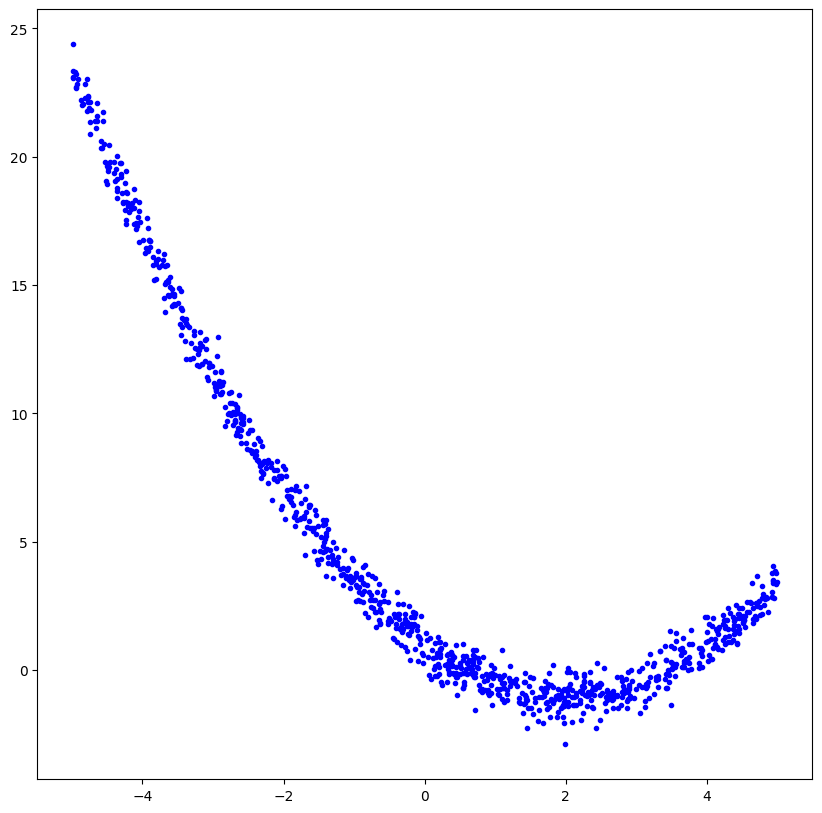

In [44]:
df = pd.read_csv('./training(in).csv',header=None)
df = df.dropna()
x = df[0].to_numpy()
y = df[1].to_numpy()


fig = plt.figure(figsize=(10,10))
plt.plot(x,y,'b.')

In [45]:
def gerar_X(x, grau):
    X = np.ones((len(x), 1))  # a0 (bias)
    for d in range(1, grau + 1):
        X = np.c_[X, x**d]
    return X

In [46]:
def batchGradientDescent(X, y, alpha, maxNumEpoch, grau):
    """Batch gradient descent solution."""
    # Get the number of training examples.
    N = len(y)

    # Ensuring that y is a column vector
    y = y.reshape(N,1)

    # Initialize error history with zeros.
    Jgd = np.zeros(maxNumEpoch+1)

    # Initialization of parameters (weights are generally random initialized).
    a = np.full((grau + 1, 1), -10.0)

    # Create matrix for parameter history.
    a_hist = np.zeros((grau+1, maxNumEpoch+1))
    # Initialize history matrix.
    a_hist[:, 0] = a.reshape(grau+1,)

    # Hypothesis function.
    yhat = X.dot(a)
    # Initial MSE.
    Jgd[0] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

    # Initialize gradient history matrix with zeros.
    grad_hist = np.zeros((grau+1, maxNumEpoch))

    # Batch gradient-descent loop.
    error = 1 # Error between consecutive epochs.
    epoch = 0 # Epoch counter.
    while(error > 1e-5 and epoch < maxNumEpoch-1):

        # Calculate the gradient vector.
        yhat = X.dot(a)
        gradients = -X.T.dot(y - yhat)

        # Update the weights.
        a = a - alpha * gradients

        # Store new weights into the matrix.
        a_hist[:, epoch+1] = a.reshape(grau+1,)

        # Calculate and store the MSE for the new weights.
        yhat = X.dot(a)
        Jgd[epoch+1] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

        # Calculate the error between consecutive epochs.
        error = np.abs(Jgd[epoch]-Jgd[epoch+1])

        # Update the gradient history.
        grad_hist[:, epoch] = gradients.reshape(grau+1,)

        # Increment the epoch.
        epoch += 1

    return a, a_hist, Jgd, grad_hist, epoch


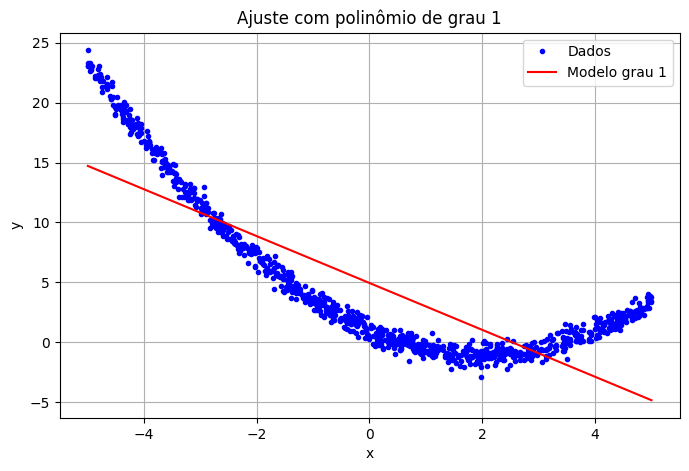

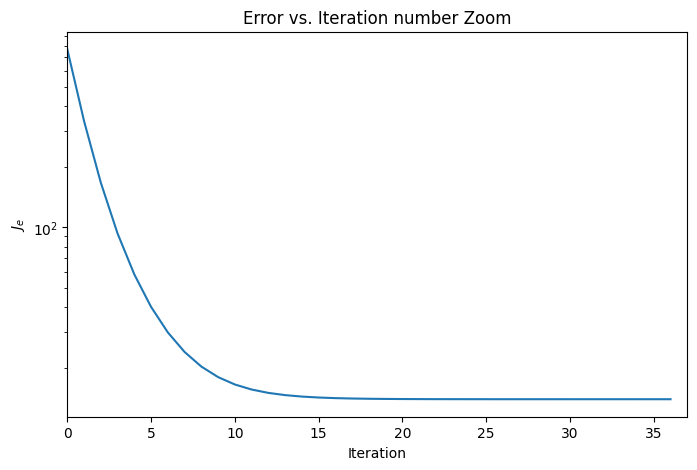

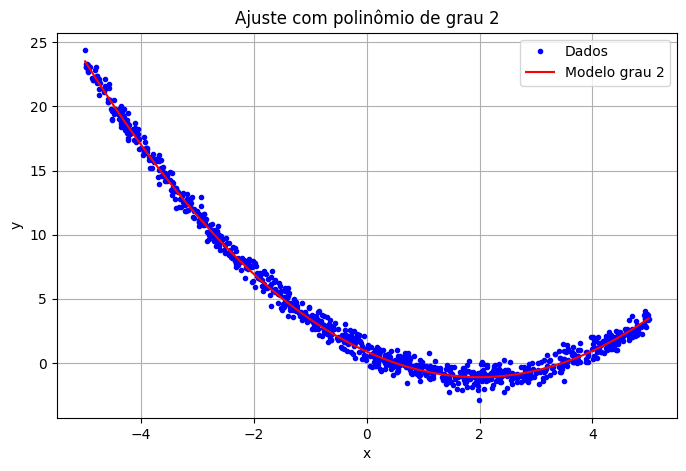

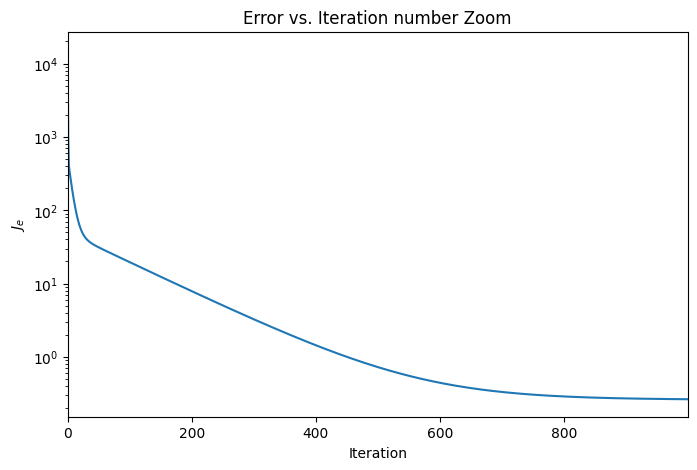

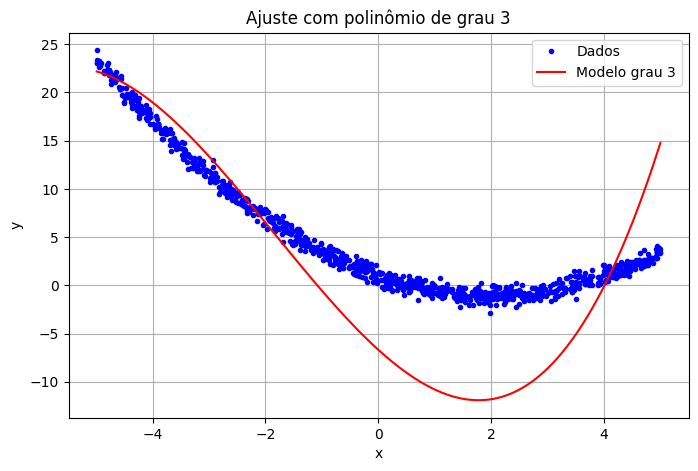

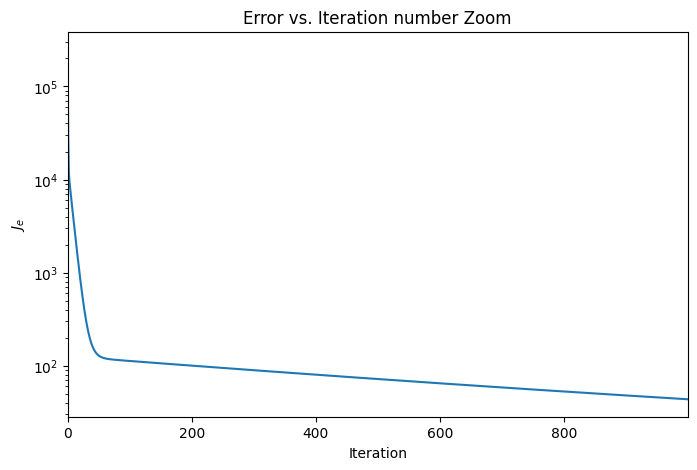

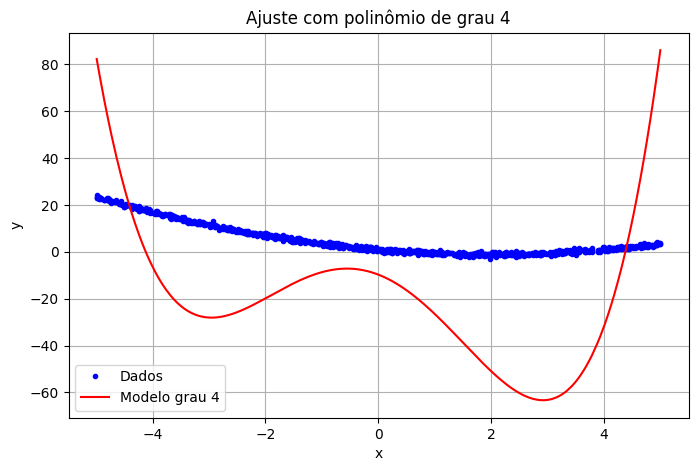

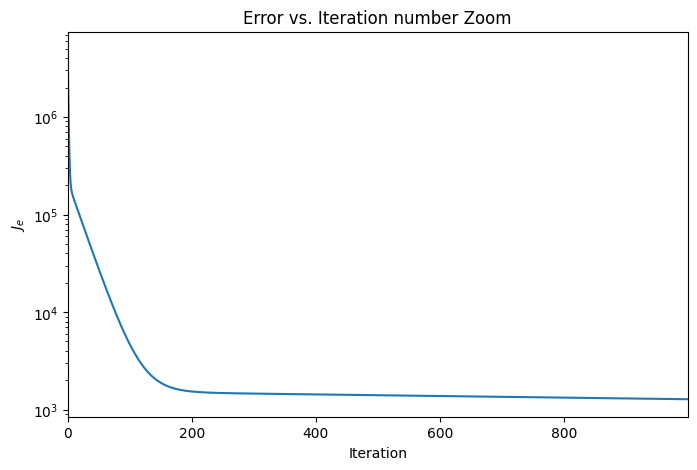

In [47]:
maxNumEpoch = 1000
for grau in range(1, 5):
    X = gerar_X(x, grau)

    # Escolhendo um valor de alpha independente por ordem de ponimômio
    if grau == 1:
        alpha = 0.0002
    elif grau == 2:
        alpha = 0.00001
    elif grau == 3:
        alpha = 0.0000006
    else:
        alpha = 0.00000001


    a, a_hist, Jgd, grad_hist, epoch = batchGradientDescent(X, y, alpha, maxNumEpoch, grau)

    # Previsão e gráfico
    x_plot = x # Alterei
    y_pred = X @ a

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'b.', label='Dados')
    plt.plot(x_plot, y_pred, 'r-', label=f'Modelo grau {grau}')
    plt.title(f'Ajuste com polinômio de grau {grau}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.title('Error vs. Iteration number')
    plt.xlim((0, epoch))
    plt.plot(np.arange(0, epoch), Jgd[0:epoch])
    plt.ylabel('$J_e$')
    plt.title('Error vs. Iteration number Zoom')
    #plt.savefig("error_vs_iteration_bgd.png", dpi=600)
    plt.show()


In [48]:
# Plotando os pesos ótimos para cada função hipótese
for grau in range(1, 5):
    X = gerar_X(x, grau)
    a = np.linalg.pinv(X.T @ X) @ X.T @ y
    y_pred = X @ a
    print(f"Coeficientes:", a)

Coeficientes: [ 4.93936197 -1.95930324]
Coeficientes: [ 0.99246638 -2.00857585  0.4987271 ]
Coeficientes: [ 9.92856814e-01 -2.01360779e+00  4.98668750e-01  3.38954584e-04]
Coeficientes: [ 9.93646209e-01 -2.01360078e+00  4.98334587e-01  3.37651799e-04
  1.57878622e-05]


In [49]:
def gradiente_descendente(X, y, alpha=1e-4, n_epochs=1000):
    M = len(y)
    y = y.reshape(-1, 1)
    a = np.zeros((X.shape[1], 1))  # inicialização dos pesos
    errors = []

    for _ in range(n_epochs):
        y_pred = X @ a
        erro = y_pred - y
        grad = (2/M) * X.T @ erro
        a -= alpha * grad  # atualização dos pesos
        mse = np.mean(erro**2)
        errors.append(mse)

    return a, errors


#Questão 1
A função que gera o menor erro quadrático é a hipótese b (polinômio de ordem 2)

In [63]:
df2 = pd.read_csv('predicting(in).csv', header=None).dropna()
x2 = df2[0].to_numpy().reshape(-1, 1)
y2 = df2[1].to_numpy().reshape(-1, 1)



In [64]:
maxNumEpoch = 2000
error_train = []
error_test = []
graus = [1, 2, 3, 4]
coeficientes = {}

for grau in graus:

    if grau == 1:
        alpha = 2e-4
    elif grau == 2:
        alpha = 1e-5
    elif grau == 3:
        alpha = 6e-7
    else:
        alpha = 1e-8

    # Gera X
    X_train = gerar_X(x, grau)
    X_val = gerar_X(x2, grau)

    # Treina o modelo
    a, _, _, _, _ = batchGradientDescent(X_train, y, alpha, maxNumEpoch, grau)
    coeficientes[grau] = a

    # Predições
    y_pred_train = X_train @ a
    y_pred_val = X_val @ a

    # Erros
    error_train.append(mean_squared_error(y, y_pred_train))
    error_test.append(mean_squared_error(y2, y_pred_val))




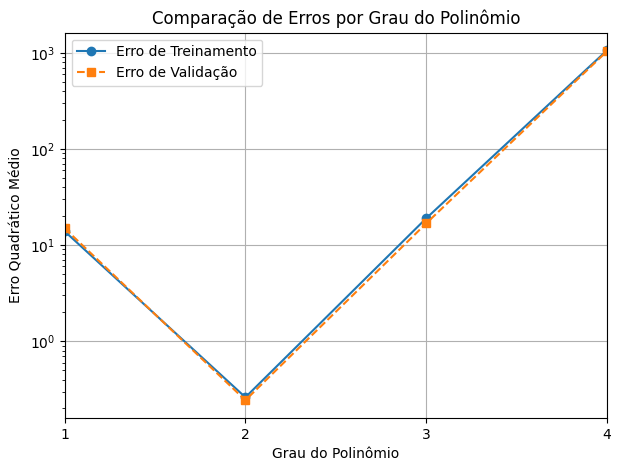

In [65]:
plt.figure(figsize=(7,5))
plt.plot(graus, error_train, 'o-', label='Erro de Treinamento')
plt.plot(graus, error_test, 's--', label='Erro de Validação')
plt.yscale('log')
plt.xticks(graus)
plt.xlim([1, 4])
plt.xlabel('Grau do Polinômio')
plt.ylabel('Erro Quadrático Médio')
plt.grid(True)
plt.legend()
plt.title('Comparação de Erros por Grau do Polinômio')
plt.show()
